CONFUSIONMATRIXDANMETRIKDENGAN
SCIKIT-LEARN

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate dataset imbalanced
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],  # 90% kelas 0, 10% kelas 1
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Hitung metrik
print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("(Format: [[TN, FP], [FN, TP]])")

# Classification Report (lengkap)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# Interpretasi manual dari CM
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretasi:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

EVALUASI MODEL
Accuracy: 0.9533
Precision: 0.8696
Recall: 0.6452
F1-Score: 0.7407

Confusion Matrix:
[[266   3]
 [ 11  20]]
(Format: [[TN, FP], [FN, TP]])

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97       269
     Class 1       0.87      0.65      0.74        31

    accuracy                           0.95       300
   macro avg       0.91      0.82      0.86       300
weighted avg       0.95      0.95      0.95       300


Interpretasi:
True Negatives: 266
False Positives: 3
False Negatives: 11
True Positives: 20


ROCCURVEDANAUC

AUC Score: 0.9076


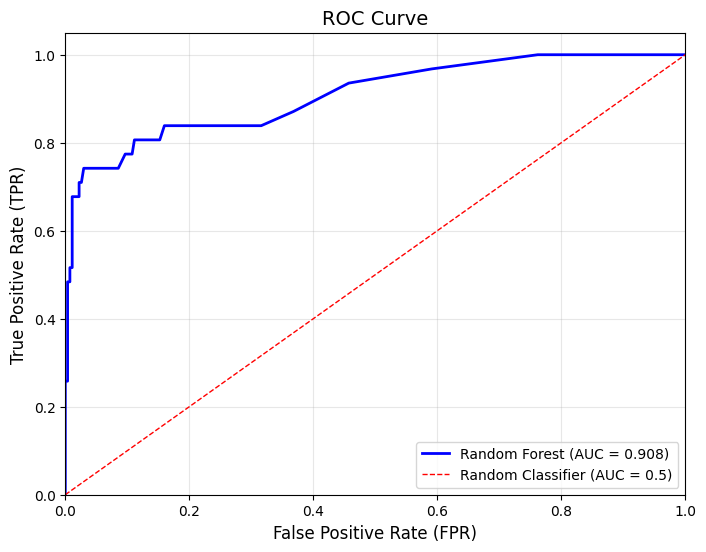

Optimal threshold (Youden's J): 0.3300
TPR at optimal threshold: 0.7419
FPR at optimal threshold: 0.0297


In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Dapatkan probabilitas (bukan kelas)
y_proba = model.predict_proba(X_test)[:, 1]  # probabilitas kelas positif

# Hitung ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

print(f"AUC Score: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Cari threshold optimal (Youden’s J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"TPR at optimal threshold: {tpr[optimal_idx]:.4f}")
print(f"FPR at optimal threshold: {fpr[optimal_idx]:.4f}")

PERBANDINGANROCCURVEBEBERAPAMODEL

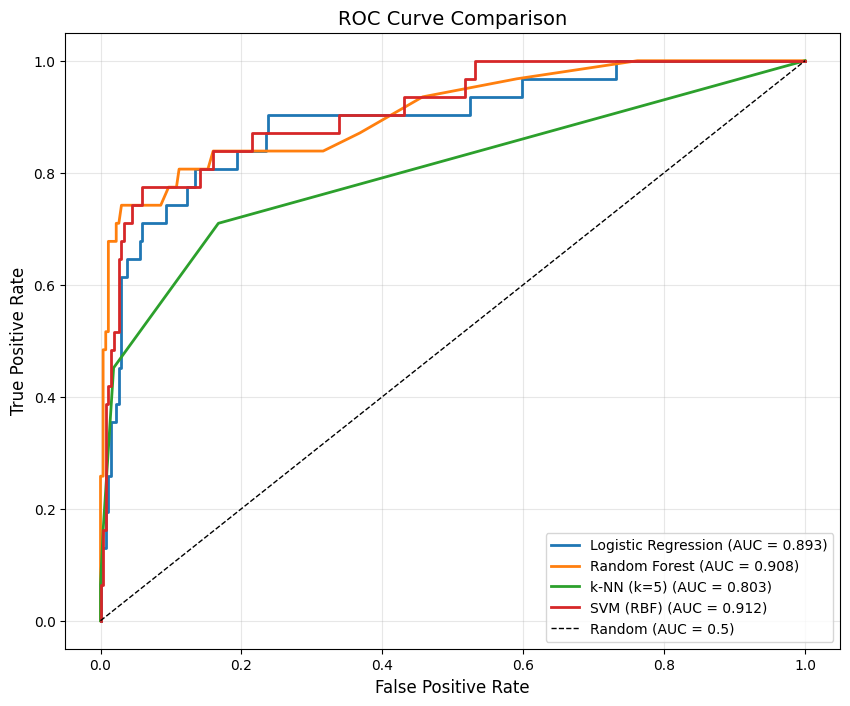

In [3]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, roc_auc_score

# Definisikan model
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# Plot ROC
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Garis random
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

# Label
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

IMPLEMENTASIK-FOLDCROSSVALIDATION

In [4]:
import numpy as np

from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier

# ================= DATA =================
# Pastikan X dan y sudah ada sebelumnya

# ============= HOLD-OUT =============
print("=" * 50)
print("HOLD-OUT VALIDATION")
print("=" * 50)

scores_holdout = []

for i in range(10):  # 10 kali ulangan
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=i)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr, y_tr)

    scores_holdout.append(model.score(X_te, y_te))

print(f"Mean accuracy: {np.mean(scores_holdout):.4f}")
print(f"Std: {np.std(scores_holdout):.4f}")

# ============= K-FOLD CV =============
print("\n" + "=" * 50)
print("K-FOLD CROSS VALIDATION")
print("=" * 50)

model = RandomForestClassifier(random_state=42)

# Standard k-Fold (tanpa stratified)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"k-Fold (k=5) - Mean: {scores_kfold.mean():.4f} (+/- {scores_kfold.std():.4f})")

# ============= STRATIFIED K-FOLD =============
print("\n" + "=" * 50)
print("STRATIFIED K-FOLD CV")
print("=" * 50)

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')

print(f"Stratified k-Fold - Mean: {scores_strat.mean():.4f} (+/- {scores_strat.std():.4f})")

# ============= PERBANDINGAN BERBAGAI K =============
print("\nPerbandingan berbagai nilai k:")

k_values = [3, 5, 7, 10]

for k in k_values:
    strat_kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')

    print(f"k={k}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

HOLD-OUT VALIDATION
Mean accuracy: 0.9487
Std: 0.0093

K-FOLD CROSS VALIDATION
k-Fold (k=5) - Mean: 0.9540 (+/- 0.0080)

STRATIFIED K-FOLD CV
Stratified k-Fold - Mean: 0.9530 (+/- 0.0117)

Perbandingan berbagai nilai k:
k=3: Mean = 0.9450, Std = 0.0135
k=5: Mean = 0.9530, Std = 0.0117
k=7: Mean = 0.9530, Std = 0.0148
k=10: Mean = 0.9490, Std = 0.0170


LEARNINGCURVEUNTUKDIAGNOSTIKMODEL

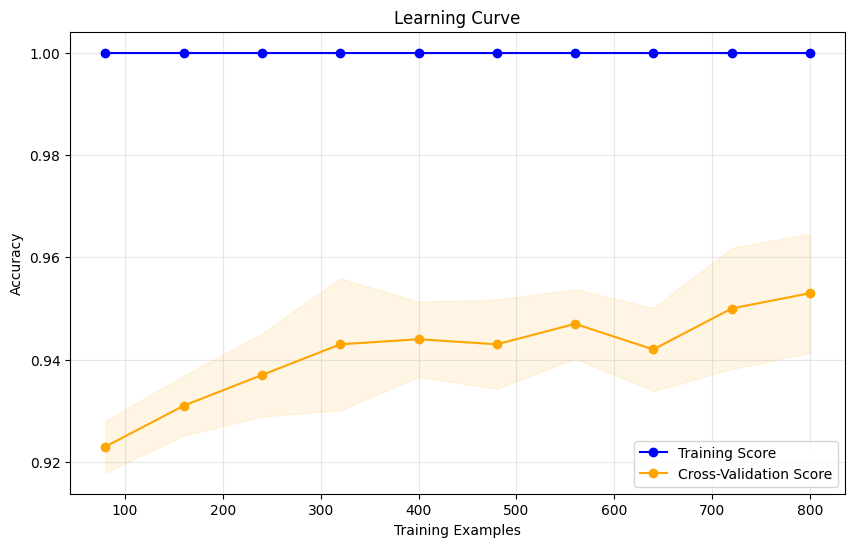

MODEL GOOD: Training ~ Validation


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# ================= LEARNING CURVE =================
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# ================= HITUNG MEAN & STD =================
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# ================= PLOT =================
plt.figure(figsize=(10, 6))

plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color='blue')

plt.fill_between(train_sizes, test_mean - test_std,
                 test_mean + test_std, alpha=0.1, color='orange')

plt.plot(train_sizes, train_mean, 'o-', color='blue',
         label='Training Score')

plt.plot(train_sizes, test_mean, 'o-', color='orange',
         label='Cross-Validation Score')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')

plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.show()

# ================= INTERPRETASI =================
gap = train_mean[-1] - test_mean[-1]

if gap > 0.1:
    print("MODEL OVERFITTING: Training >> Validation")
elif gap < -0.05:
    print("MODEL UNDERFITTING: Training < Validation")
else:
    print("MODEL GOOD: Training ~ Validation")